In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

# Auto-reload makes it so if you change the .py files, the notebook updates instantly
%load_ext autoreload
%autoreload 2

from testing.speaker_test import generate_chirp_file
from testing.mic_test import analyze_recording
from testing.channel_response import plot_hardware_response

In [2]:
files = ["../data/bin/tx1.wav"]

# Generate the test sound

In [3]:
generate_chirp_file(output_path="../data/bin/chirp_test.wav")

Generating chirp from 20Hz to 24000Hz over 5.0 seconds...
Success! Saved to ../data/bin/chirp_test.wav


c:\Users\Ishaan\Ishaan\IITM\Sem6\CommSys\Project\transceiver-project\src\testing\mic_test.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(input_path)


Loaded ../data/bin/tx1.wav. Sample rate: 44100 Hz


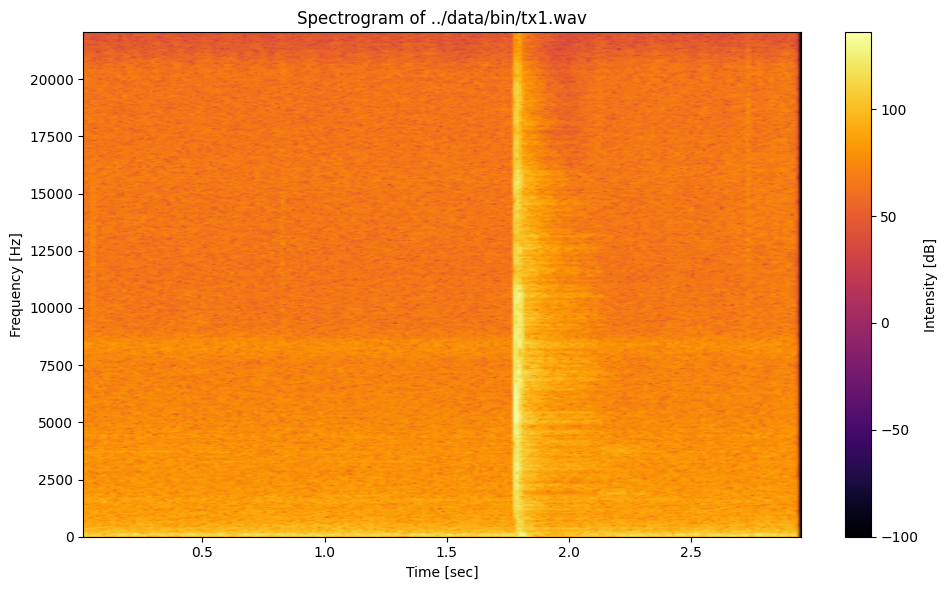

Error loading files: [Errno 2] No such file or directory: '../data/chirp_test.wav'


In [4]:
for file in files:
    try:
        analyze_recording(file)
        plot_hardware_response('../data/chirp_test.wav', file)
    except Exception as e:
        print(f"Error processing {file}: {e}")

# Analyze setup recordings


# Decide the Best Setup:

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_25508\323662290.py:19: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(path)


[tx1.wav] Usable bandwidth up to ~15816 Hz


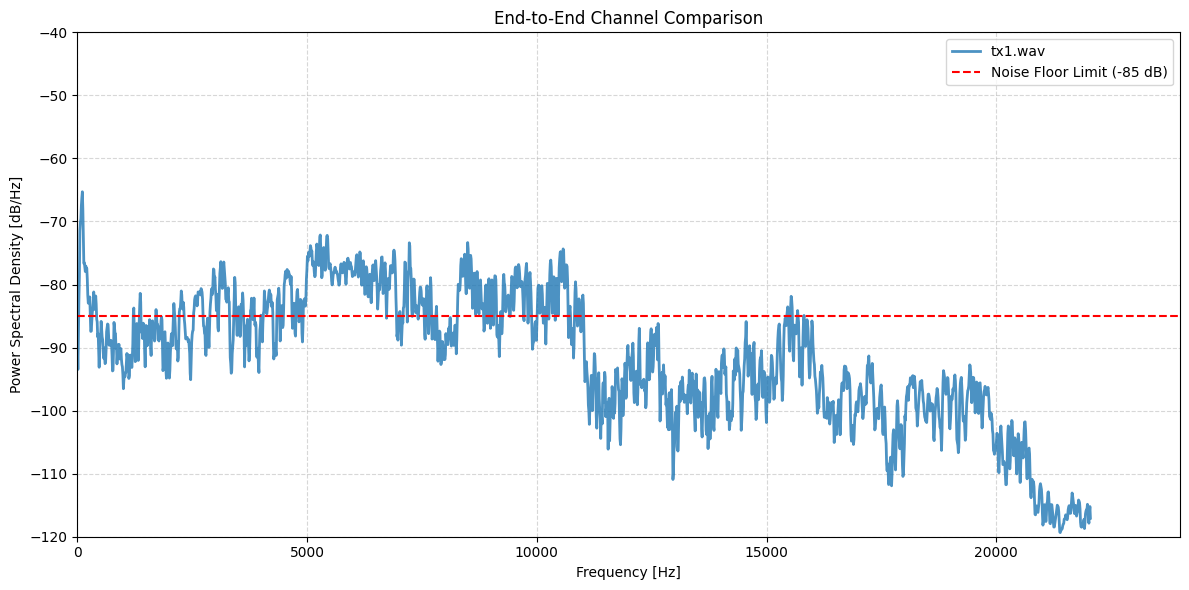

--------------------------------------------------
🏆 WINNER: tx1.wav (Cutoff: 15816 Hz)
--------------------------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

# Dictionary mapping setup names to their file paths
files_dict = {os.path.basename(f): f for f in files}

plt.figure(figsize=(12, 6))
best_setup = None
max_cutoff_freq = 0

# The dB level where we consider the signal to be "dead" (lost in noise)
# You can tweak this based on what the graph looks like
THRESHOLD_DB = -85 

for name, path in files_dict.items():
    try:
        fs, data = wavfile.read(path)
        
        # Convert stereo to mono if necessary
        if len(data.shape) > 1: 
            data = data.mean(axis=1)
            
        # Normalize to ensure fair volume comparison
        data = data / np.max(np.abs(data))
        
        # Calculate Power Spectral Density
        f, Pxx = welch(data, fs, nperseg=4096)
        Pxx_dB = 10 * np.log10(Pxx + 1e-12)
        
        # Plot the curve
        plt.plot(f, Pxx_dB, label=name, alpha=0.8, linewidth=2)
        
        # METRIC: Find the highest frequency above 1kHz that survives the threshold
        valid_indices = np.where((f > 1000) & (Pxx_dB > THRESHOLD_DB))[0]
        
        if len(valid_indices) > 0:
            cutoff = f[valid_indices[-1]]
            print(f"[{name}] Usable bandwidth up to ~{cutoff:.0f} Hz")
            
            if cutoff > max_cutoff_freq:
                max_cutoff_freq = cutoff
                best_setup = name
        else:
             print(f"[{name}] Signal too weak to measure.")

    except Exception as e:
        print(f"Error processing {name}: {e}")

# Formatting the graph
plt.title('End-to-End Channel Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB/Hz]')
plt.xlim(0, 24000)
# Set Y-axis limits based on typical acoustic recording levels
plt.ylim(-120, -40) 
plt.axhline(THRESHOLD_DB, color='red', linestyle='--', label=f'Noise Floor Limit ({THRESHOLD_DB} dB)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("-" * 50)
if best_setup:
    print(f"🏆 WINNER: {best_setup} (Cutoff: {max_cutoff_freq:.0f} Hz)")
else:
    print("Could not determine a winner. Check the data.")
print("-" * 50)

# Finding SNR


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

def calculate_acoustic_snr(
    audio_path,
    analysis_start=0.0,
    analysis_duration=None,
    window_duration=0.01,
    noise_fraction=0.2,
    threshold_db_offset=6
):
    """
    Estimates SNR using:
    - Known noise region (first noise_fraction)
    - Active window detection for signal

    Parameters
    ----------
    noise_fraction : float
        Fraction of selected segment that is pure noise (e.g., 0.2)
    threshold_db_offset : float
        dB above noise floor to classify signal presence
    """

    # 1. Load
    fs, data = wavfile.read(audio_path)

    if len(data.shape) > 1:
        data = data.mean(axis=1)

    total_duration = len(data) / fs

    start_sample = int(max(0.0, analysis_start) * fs)

    if analysis_duration is None:
        end_sample = len(data)
    elif 0.0 < analysis_duration <= 1.0:
        end_sample = start_sample + int(total_duration * analysis_duration * fs)
    else:
        end_sample = start_sample + int(analysis_duration * fs)

    end_sample = min(len(data), end_sample)

    if start_sample >= end_sample:
        raise ValueError("Invalid analysis range.")

    data = data[start_sample:end_sample].astype(float)

    if data.size == 0:
        raise ValueError("Empty segment.")

    # Normalize (does not affect SNR)
    peak = np.max(np.abs(data))
    if peak == 0:
        raise ValueError("Audio is silent.")
    data = data / peak

    # 2. Windowing
    window_samples = max(1, int(fs * window_duration))
    num_windows = len(data) // window_samples

    if num_windows < 4:
        raise ValueError("Too few windows.")

    window_powers = []
    for i in range(num_windows):
        window = data[i * window_samples:(i + 1) * window_samples]
        power = np.mean(window**2)
        window_powers.append(power)

    window_powers = np.array(window_powers)

    # 3. TRUE noise estimation (first noise_fraction)
    total_samples = len(data)
    noise_end_sample = int(noise_fraction * total_samples)

    if noise_end_sample <= 0 or noise_end_sample >= total_samples:
        raise ValueError("Invalid noise_fraction.")

    noise_segment = data[:noise_end_sample]
    noise_power = np.mean(noise_segment**2)

    # Convert to dB for thresholding
    window_powers_db = 10 * np.log10(window_powers + 1e-12)
    noise_power_db = 10 * np.log10(noise_power + 1e-12)

    # 4. Detect active signal windows
    threshold_db = noise_power_db + threshold_db_offset
    active_mask = window_powers_db > threshold_db

    if not np.any(active_mask):
        raise ValueError("No signal detected above threshold.")

    active_powers = window_powers[active_mask]

    # Signal + noise power over active region
    total_power = np.mean(active_powers)

    # Remove noise contribution
    signal_power = total_power - noise_power

    if signal_power <= 0:
        raise ValueError("Signal power <= 0. Check assumptions.")

    # 5. SNR
    snr_db = 10 * np.log10(signal_power / noise_power)

    # --- Visualization ---
    plt.figure(figsize=(12, 4))
    time_axis = np.arange(num_windows) * window_duration + analysis_start

    plt.plot(time_axis, window_powers_db, label="Window Power (dB)", color='blue')

    plt.axhline(10 * np.log10(signal_power + 1e-12),
                color='green', linestyle='--',
                label="Signal Power (denoised)")

    plt.axhline(noise_power_db,
                color='red', linestyle='--',
                label="Noise Power (true)")

    plt.axhline(10 * np.log10(total_power + 1e-12),
                color='orange', linestyle='--',
                label="Signal+Noise Power")

    plt.title(
        f"Power Envelope | Segment {analysis_start:.2f}s to {end_sample/fs:.2f}s | SNR: {snr_db:.2f} dB"
    )
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Power (dBFS)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return snr_db

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_25508\2445969824.py:27: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(audio_path)


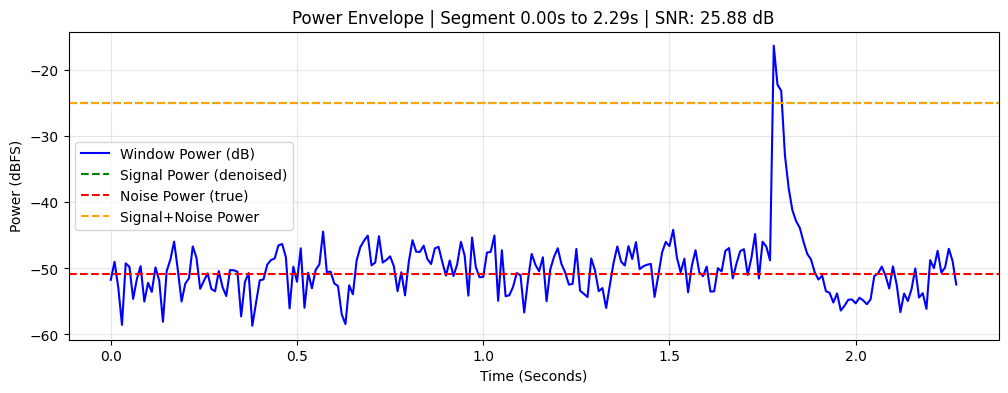

----------------------------------------
🥇 Estimated Acoustic SNR: 25.88 dB
----------------------------------------


In [7]:
# -------- Run --------

audio_array = files

for i in audio_array:
    try:
        snr = calculate_acoustic_snr(
            i,
            analysis_start=0.0,
            analysis_duration=0.77,   # IMPORTANT: don't truncate your noise region
            window_duration=0.01,
            noise_fraction=0.2,
            threshold_db_offset=6
        )
        print("-" * 40)
        print(f"🥇 Estimated Acoustic SNR: {snr:.2f} dB")
        print("-" * 40)
    except Exception as e:
        print(f"Error calculating SNR for {i}: {e}")